In [61]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, log_loss, roc_auc_score
from scipy.optimize import minimize
import optuna
import warnings
warnings.filterwarnings('ignore')

# ====================================================
# 🎛️ [CONTROL PANEL] 전역 설정 - 여기만 수정하세요!
# ====================================================
PROBLEM_TYPE = "CLASSIFICATION"  # "REGRESSION" (회귀) 또는 "CLASSIFICATION" (분류)
TARGET_COL = "gender"        # 타겟 컬럼명
ID_COL = "custid"         # ID 컬럼명
CV_SPLITS = 5                # Cross-Validation Fold 수
RANDOM_STATE = 42            # Random Seed

# ⭐ 평가지표 설정 (새로 추가)
METRIC = "AUC"  # 회귀: "RMSE", "MAE", "R2" / 분류: "LOGLOSS", "AUC", "ACCURACY"

# Optuna Trials 설정
OPTUNA_TRIALS = {
    "Ridge": 50,
    "XGBoost": 50,
    "LightGBM": 50,
    "Weights": 2000
}

# 경로 설정
OOF_SUBMISSION_DIR = r"C:\SEMIN\Project\ML_FINAL\4.OOF_SUBMISSION"
TRAIN_FILE_PATH = r"C:\SEMIN\Project\ML_FINAL\1.BASE\train.csv"
OUTPUT_DIR = r"C:\SEMIN\Project\ML_FINAL\5.ENSEMBLE_SUBMISSION"

# 출력 디렉토리 생성
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# 시각화 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ====================================================
# 🛠️ 범용 유틸리티 함수 (회귀/분류 자동 스위칭)
# ====================================================
def get_cv_strategy(y):
    """문제 유형에 따라 CV 방식 자동 선택"""
    if PROBLEM_TYPE == "CLASSIFICATION":
        return StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    else:
        return KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def get_metric_function(y_true, y_pred):
    """문제 유형 및 선택된 지표에 따라 평가 지표 자동 계산"""
    
    if PROBLEM_TYPE == "CLASSIFICATION":
        if METRIC == "LOGLOSS":
            return log_loss(y_true, y_pred)
        elif METRIC == "AUC":
            return -roc_auc_score(y_true, y_pred)  # 음수: 최소화 방향 변환
        elif METRIC == "ACCURACY":
            pred_class = (y_pred >= 0.5).astype(int)
            return -np.mean(y_true == pred_class)  # 음수: 최소화 방향 변환
        else:
            raise ValueError(f"Unknown classification metric: {METRIC}")
    
    else:  # REGRESSION
        if METRIC == "RMSE":
            return np.sqrt(mean_squared_error(y_true, y_pred))
        elif METRIC == "MAE":
            return mean_absolute_error(y_true, y_pred)
        elif METRIC == "R2":
            return -r2_score(y_true, y_pred)  # 음수: 최소화 방향 변환
        elif METRIC == "MAPE":
            return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
        else:
            raise ValueError(f"Unknown regression metric: {METRIC}")

def get_meta_model(params=None):
    """스태킹 메타 모델 자동 선택 (Ridge vs LogisticRegression)"""
    if PROBLEM_TYPE == "CLASSIFICATION":
        return LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', max_iter=1000, **(params if params else {}))
    else:
        return Ridge(random_state=RANDOM_STATE, **(params if params else {}))

def get_tree_model(model_type, params):
    """XGBoost/LightGBM 모델 자동 선택 (Regressor vs Classifier)"""
    if model_type == 'xgb':
        if PROBLEM_TYPE == "CLASSIFICATION":
            return xgb.XGBClassifier(**params)
        return xgb.XGBRegressor(**params)
    elif model_type == 'lgb':
        if PROBLEM_TYPE == "CLASSIFICATION":
            return lgb.LGBMClassifier(**params)
        return lgb.LGBMRegressor(**params)

def get_prediction(model, X):
    """모델 예측 자동 처리 (회귀: predict, 분류: predict_proba)"""
    if PROBLEM_TYPE == "CLASSIFICATION":
        return model.predict_proba(X)[:, 1]  # 1번 클래스 확률
    else:
        return model.predict(X)

# ====================================================
# 📊 설정 정보 출력
# ====================================================
print("="*60)
print("🎯 앙상블 파이프라인 설정 정보")
print("="*60)
print(f"📌 문제 유형: {PROBLEM_TYPE}")
print(f"📌 타겟 컬럼: {TARGET_COL}")
print(f"📌 ID 컬럼: {ID_COL}")
print(f"📌 CV Splits: {CV_SPLITS}")
print(f"📌 Random State: {RANDOM_STATE}")
print(f"📌 Optuna Trials: {OPTUNA_TRIALS}")
print("="*60)
print(f"📁 OOF Directory: {OOF_SUBMISSION_DIR}")
print(f"📁 Train File: {TRAIN_FILE_PATH}")
print(f"📁 Output Directory: {OUTPUT_DIR}")
print("="*60)
print("✅ 라이브러리 및 전역 설정 로드 완료!")
print("="*60)

🎯 앙상블 파이프라인 설정 정보
📌 문제 유형: CLASSIFICATION
📌 타겟 컬럼: gender
📌 ID 컬럼: custid
📌 CV Splits: 5
📌 Random State: 42
📌 Optuna Trials: {'Ridge': 50, 'XGBoost': 50, 'LightGBM': 50, 'Weights': 2000}
📁 OOF Directory: C:\SEMIN\Project\ML_FINAL\4.OOF_SUBMISSION
📁 Train File: C:\SEMIN\Project\ML_FINAL\1.BASE\train.csv
📁 Output Directory: C:\SEMIN\Project\ML_FINAL\5.ENSEMBLE_SUBMISSION
✅ 라이브러리 및 전역 설정 로드 완료!


In [62]:
# OOF 파일 로드
oof_data = {}
for file in sorted(Path(OOF_SUBMISSION_DIR).glob('oof_*_semin.csv')):
    model_name = file.stem.replace('oof_', '').replace('_semin', '')
    df = pd.read_csv(file)
    oof_data[model_name] = df
    print(f"  ✓ Loaded OOF: {model_name:12s} - {len(df):,} rows")

# Submission 파일 로드
submission_data = {}
for file in sorted(Path(OOF_SUBMISSION_DIR).glob('submission_*_semin.csv')):
    model_name = file.stem.replace('submission_', '').replace('_semin', '')
    df = pd.read_csv(file)
    submission_data[model_name] = df
    print(f"  ✓ Loaded Submission: {model_name:12s} - {len(df):,} rows")

print(f"\n총 {len(oof_data)}개 모델의 OOF 및 Submission 로드 완료")

  ✓ Loaded OOF: CatBoost     - 30,000 rows
  ✓ Loaded OOF: ET           - 30,000 rows
  ✓ Loaded OOF: LGBM         - 30,000 rows
  ✓ Loaded OOF: Linear       - 30,000 rows
  ✓ Loaded OOF: MLP          - 30,000 rows
  ✓ Loaded OOF: RealMLP      - 30,000 rows
  ✓ Loaded OOF: RF           - 30,000 rows
  ✓ Loaded OOF: XGBoost      - 30,000 rows
  ✓ Loaded Submission: CatBoost     - 19,995 rows
  ✓ Loaded Submission: ET           - 19,995 rows
  ✓ Loaded Submission: LGBM         - 19,995 rows
  ✓ Loaded Submission: Linear       - 19,995 rows
  ✓ Loaded Submission: MLP          - 19,995 rows
  ✓ Loaded Submission: RealMLP      - 19,995 rows
  ✓ Loaded Submission: RF           - 19,995 rows
  ✓ Loaded Submission: XGBoost      - 19,995 rows

총 8개 모델의 OOF 및 Submission 로드 완료


In [63]:
# 실제 Train 파일에서 타겟 로드
train_df = pd.read_csv(TRAIN_FILE_PATH)

if TARGET_COL not in train_df.columns:
    raise ValueError(f"Error: '{TARGET_COL}' 컬럼이 train.csv에 없습니다. 전역 설정(TARGET_COL)을 확인하세요.")

target_df = train_df[[ID_COL, TARGET_COL]].copy()

print(f"✅ Target 로드 완료: {target_df.shape}")
print(f"\nTarget 통계:")
print(target_df[TARGET_COL].describe())

✅ Target 로드 완료: (30000, 2)

Target 통계:
count    30000.000000
mean         0.303933
std          0.459962
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: gender, dtype: float64


In [64]:
# 행렬 생성 함수
def create_oof_matrix(oof_data):
    oof_dfs = []
    model_names = []
    
    for model_name, df in sorted(oof_data.items()):
        oof_dfs.append(df[[ID_COL, TARGET_COL]].rename(columns={TARGET_COL: model_name}))
        model_names.append(model_name)
    
    oof_matrix = oof_dfs[0]
    for df in oof_dfs[1:]:
        oof_matrix = oof_matrix.merge(df, on=ID_COL, how='outer')
    
    return oof_matrix, model_names

def create_submission_matrix(submission_data):
    sub_dfs = []
    model_names = []
    
    for model_name, df in sorted(submission_data.items()):
        sub_dfs.append(df[[ID_COL, TARGET_COL]].rename(columns={TARGET_COL: model_name}))
        model_names.append(model_name)
    
    sub_matrix = sub_dfs[0]
    for df in sub_dfs[1:]:
        sub_matrix = sub_matrix.merge(df, on=ID_COL, how='outer')
    
    return sub_matrix, model_names

# 행렬 생성
oof_matrix, model_names = create_oof_matrix(oof_data)
sub_matrix, _ = create_submission_matrix(submission_data)

print(f"✅ OOF Matrix: {oof_matrix.shape}")
print(f"✅ Submission Matrix: {sub_matrix.shape}")
print(f"\n모델 목록: {model_names}")

✅ OOF Matrix: (30000, 9)
✅ Submission Matrix: (19995, 9)

모델 목록: ['CatBoost', 'ET', 'LGBM', 'Linear', 'MLP', 'RF', 'RealMLP', 'XGBoost']


---
## 개별 모델 성능 평가

In [65]:
def evaluate_model(model_name, oof_data, target_df):
    """개별 모델 성능 평가 (회귀/분류 자동 처리)"""
    oof_pred = oof_data[model_name]
    merged = target_df.merge(oof_pred, on=ID_COL, suffixes=('_true', '_pred'))
    
    y_true = merged[f'{TARGET_COL}_true'].values
    y_pred = merged[f'{TARGET_COL}_pred'].values
    
    if PROBLEM_TYPE == "CLASSIFICATION":
        # 분류: LogLoss, AUC
        logloss = log_loss(y_true, y_pred)
        auc = roc_auc_score(y_true, y_pred)
        return {'model': model_name, 'logloss': logloss, 'auc': auc}
    else:
        # 회귀: RMSE, MAE, R²
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        return {'model': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2}

# 모든 모델 평가
print(f"\n=== 📊 개별 모델 성능 평가 ({PROBLEM_TYPE} Mode) ===\n")
results = []
for model_name in model_names:
    score = evaluate_model(model_name, oof_data, target_df)
    results.append(score)
    if PROBLEM_TYPE == "CLASSIFICATION":
        print(f"{model_name:12s}: LogLoss={score['logloss']:.6f}, AUC={score['auc']:.6f}")
    else:
        print(f"{model_name:12s}: RMSE={score['rmse']:.6f}, MAE={score['mae']:.6f}, R²={score['r2']:.6f}")

results_df = pd.DataFrame(results)
if PROBLEM_TYPE == "CLASSIFICATION":
    results_df = results_df.sort_values('logloss')  # LogLoss 낮을수록 좋음
    print(f"\n=== 성능 순위 (LogLoss 기준, 낮을수록 좋음) ===")
else:
    results_df = results_df.sort_values('rmse')  # RMSE 낮을수록 좋음
    print(f"\n=== 성능 순위 (RMSE 기준, 낮을수록 좋음) ===")

display(results_df)

# 결과 저장
results_df.to_csv(f"{OUTPUT_DIR}/model_performance.csv", index=False)
print(f"\n✅ Saved: model_performance.csv")


=== 📊 개별 모델 성능 평가 (CLASSIFICATION Mode) ===

CatBoost    : LogLoss=0.552802, AUC=0.708098
ET          : LogLoss=0.559947, AUC=0.702866
LGBM        : LogLoss=0.547894, AUC=0.714472
Linear      : LogLoss=0.554729, AUC=0.707464
MLP         : LogLoss=1.957396, AUC=0.632275
RF          : LogLoss=0.556732, AUC=0.703997
RealMLP     : LogLoss=0.554343, AUC=0.704669
XGBoost     : LogLoss=0.644784, AUC=0.690497

=== 성능 순위 (LogLoss 기준, 낮을수록 좋음) ===


,model,logloss,auc
2,LGBM,0.547894,0.714472
0,CatBoost,0.552802,0.708098
6,RealMLP,0.554343,0.704669
3,Linear,0.554729,0.707464
5,RF,0.556732,0.703997
1,ET,0.559947,0.702866
7,XGBoost,0.644784,0.690497
4,MLP,1.957396,0.632275



✅ Saved: model_performance.csv


---
## Simple Average Ensemble

In [66]:
# Simple Average 계산
oof_avg = oof_matrix[model_names].mean(axis=1)
sub_avg = sub_matrix[model_names].mean(axis=1)

# OOF 성능 평가 (⭐ get_metric_function 사용으로 통일)
merged = target_df.merge(pd.DataFrame({ID_COL: oof_matrix[ID_COL], TARGET_COL: oof_avg}), 
                         on=ID_COL, suffixes=('_true', '_pred'))
y_true = merged[f'{TARGET_COL}_true'].values
y_pred = merged[f'{TARGET_COL}_pred'].values

score_avg = get_metric_function(y_true, y_pred)  # ⭐ 통일된 함수 사용

if PROBLEM_TYPE == "CLASSIFICATION":
    auc_avg = roc_auc_score(y_true, y_pred)
    logloss_avg = log_loss(y_true, y_pred)
    print(f"Simple Average 성능 ({PROBLEM_TYPE}):")
    print(f"  {METRIC}: {score_avg:.6f}")
    print(f"  LogLoss: {logloss_avg:.6f}")
    print(f"  AUC:     {auc_avg:.6f}")
else:
    mae_avg = mean_absolute_error(y_true, y_pred)
    r2_avg = r2_score(y_true, y_pred)
    print(f"Simple Average 성능 ({PROBLEM_TYPE}):")
    print(f"  {METRIC}: {score_avg:.6f}")
    print(f"  MAE:  {mae_avg:.6f}")
    print(f"  R²:   {r2_avg:.6f}")

# 결과 저장
pd.DataFrame({ID_COL: oof_matrix[ID_COL], TARGET_COL: oof_avg}).to_csv(f"{OUTPUT_DIR}/oof_simple_average.csv", index=False)
pd.DataFrame({ID_COL: sub_matrix[ID_COL], TARGET_COL: sub_avg}).to_csv(f"{OUTPUT_DIR}/submission_simple_average.csv", index=False)
print(f"\n✅ Saved: oof_simple_average.csv, submission_simple_average.csv")

Simple Average 성능 (CLASSIFICATION):
  AUC: -0.710798
  LogLoss: 0.550823
  AUC:     0.710798

✅ Saved: oof_simple_average.csv, submission_simple_average.csv


---
## Scipy 가중치 최적화

In [67]:
def optimize_weights_scipy(oof_matrix, target_df, model_names):
    """Scipy 최적화로 최적 가중치 찾기 (회귀/분류 자동 처리)"""
    merged = target_df.merge(oof_matrix, on=ID_COL)
    y_true = merged[TARGET_COL].values
    X_preds = merged[model_names].values
    
    def objective(weights):
        ensemble_pred = np.dot(X_preds, weights)
        return get_metric_function(y_true, ensemble_pred)
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0, 1) for _ in range(len(model_names))]
    initial_weights = np.ones(len(model_names)) / len(model_names)
    
    result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints, options={'maxiter': 1000})
    
    return dict(zip(model_names, result.x)), result.fun

optimal_weights_scipy, score_scipy = optimize_weights_scipy(oof_matrix, target_df, model_names)

# ✅ METRIC 변수 그대로 사용
metric_name = METRIC 
print(f"🎯 Scipy Optimal {metric_name}: {score_scipy:.6f}")
print(f"\nOptimal Weights (Scipy - {PROBLEM_TYPE}):")
for model, weight in sorted(optimal_weights_scipy.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model:12s}: {weight:.6f}")

# 최적 가중치로 앙상블 생성
oof_scipy = sum(oof_matrix[model] * optimal_weights_scipy[model] for model in model_names)
sub_scipy = sum(sub_matrix[model] * optimal_weights_scipy[model] for model in model_names)

# 결과 저장
pd.DataFrame({ID_COL: oof_matrix[ID_COL], TARGET_COL: oof_scipy}).to_csv(f"{OUTPUT_DIR}/oof_scipy_weights.csv", index=False)
pd.DataFrame({ID_COL: sub_matrix[ID_COL], TARGET_COL: sub_scipy}).to_csv(f"{OUTPUT_DIR}/submission_scipy_weights.csv", index=False)
print(f"\n✅ Saved: oof_scipy_weights.csv, submission_scipy_weights.csv")

🎯 Scipy Optimal AUC: -0.713505

Optimal Weights (Scipy - CLASSIFICATION):
  XGBoost     : 0.130750
  CatBoost    : 0.130167
  ET          : 0.130167
  LGBM        : 0.130167
  Linear      : 0.130167
  RF          : 0.130167
  RealMLP     : 0.130167
  MLP         : 0.088250

✅ Saved: oof_scipy_weights.csv, submission_scipy_weights.csv


---
## Optuna 가중치 최적화

In [68]:
def objective_weights(trial):
    """Optuna 가중치 최적화 (회귀/분류 자동 처리)"""
    weights_raw = [trial.suggest_float(f'weight_{model}', 0.0, 1.0) for model in model_names]
    weights_sum = sum(weights_raw)
    if weights_sum == 0:
        return 1e10
    
    weights = [w / weights_sum for w in weights_raw]
    
    merged = target_df.merge(oof_matrix, on=ID_COL)
    y_true = merged[TARGET_COL].values
    X_preds = merged[model_names].values
    
    ensemble_pred = np.dot(X_preds, weights)
    return get_metric_function(y_true, ensemble_pred)

print(f"\n=== 🔬 Optuna 가중치 최적화 ({PROBLEM_TYPE}) ===\n")
study_weights = optuna.create_study(direction='minimize', study_name='Weighted_Ensemble')
study_weights.optimize(objective_weights, n_trials=OPTUNA_TRIALS["Weights"], show_progress_bar=True)

# 가중치 추출
weights_raw = [study_weights.best_params[f'weight_{model}'] for model in model_names]
weights_sum = sum(weights_raw)
optuna_weights = {model: w/weights_sum for model, w in zip(model_names, weights_raw)}

metric_name = METRIC
print(f"\n🎯 Optuna Optimal {metric_name}: {study_weights.best_value:.6f}")
print(f"\nOptimal Weights (Optuna - {PROBLEM_TYPE}):")
for model, weight in sorted(optuna_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model:12s}: {weight:.6f}")

# 최적 가중치로 앙상블 생성
oof_optuna = sum(oof_matrix[model] * optuna_weights[model] for model in model_names)
sub_optuna = sum(sub_matrix[model] * optuna_weights[model] for model in model_names)

# 결과 저장
pd.DataFrame({ID_COL: oof_matrix[ID_COL], TARGET_COL: oof_optuna}).to_csv(f"{OUTPUT_DIR}/oof_optuna_weights.csv", index=False)
pd.DataFrame({ID_COL: sub_matrix[ID_COL], TARGET_COL: sub_optuna}).to_csv(f"{OUTPUT_DIR}/submission_optuna_weights.csv", index=False)
print(f"\n✅ Saved: oof_optuna_weights.csv, submission_optuna_weights.csv")

[I 2025-12-08 16:18:26,966] A new study created in memory with name: Weighted_Ensemble



=== 🔬 Optuna 가중치 최적화 (CLASSIFICATION) ===



  0%|          | 0/2000 [00:00<?, ?it/s]

[I 2025-12-08 16:18:26,982] Trial 0 finished with value: -0.7049655120356986 and parameters: {'weight_CatBoost': 0.7969839342702124, 'weight_ET': 0.7953574999102085, 'weight_LGBM': 0.3655417169623124, 'weight_Linear': 0.3943563458347691, 'weight_MLP': 0.8865178619211653, 'weight_RF': 0.6305032796519927, 'weight_RealMLP': 0.2130607388271154, 'weight_XGBoost': 0.95051551865707}. Best is trial 0 with value: -0.7049655120356986.
[I 2025-12-08 16:18:26,991] Trial 1 finished with value: -0.7017440713198946 and parameters: {'weight_CatBoost': 0.1772671662185974, 'weight_ET': 0.14643372988893832, 'weight_LGBM': 0.16518217409663716, 'weight_Linear': 0.2372457360482061, 'weight_MLP': 0.4316819956085922, 'weight_RF': 0.26002492347197825, 'weight_RealMLP': 0.1337407333078412, 'weight_XGBoost': 0.4470480221388834}. Best is trial 0 with value: -0.7049655120356986.
[I 2025-12-08 16:18:27,000] Trial 2 finished with value: -0.696563145666542 and parameters: {'weight_CatBoost': 0.0657541935343916, 'weig

In [69]:
# ====================================================
# Hill Climbing 앙상블 (회귀/분류 범용)
# ====================================================
def universal_hill_climbing(oof_df, target, model_cols, iterations=1000):
    """
    Hill Climbing 알고리즘 - 회귀/분류 자동 처리
    모델을 하나씩 추가하며 성능이 좋아지는 방향으로만 진행
    """
    current_preds = np.zeros(len(oof_df))
    model_preds = oof_df[model_cols].values
    y_true = target.values
    
    selected_indices = []
    best_score = float('inf')
    
    metric_name = METRIC
    print(f"⛰️ Hill Climbing ({PROBLEM_TYPE} Mode, Metric: {metric_name}) 시작...\n")
    
    for i in range(iterations):
        step_best_score = float('inf')
        step_best_model_idx = -1
        
        for idx in range(len(model_cols)):
            # 앙상블 평균 계산
            temp_preds = (current_preds + model_preds[:, idx]) / (i + 1)
            
            # 메트릭 계산 (함수가 알아서 RMSE/LogLoss 계산)
            score = get_metric_function(y_true, temp_preds)
            
            if score < step_best_score:
                step_best_score = score
                step_best_model_idx = idx
        
        # 이번 단계 최고 모델 추가
        selected_indices.append(step_best_model_idx)
        current_preds += model_preds[:, step_best_model_idx]
        best_score = step_best_score
        
        if (i+1) % 100 == 0:
            print(f"  Iteration {i+1:4d} | Best {metric_name}: {best_score:.6f} | Added: {model_cols[step_best_model_idx]}")
            
    # 최종 가중치 계산 (선택된 횟수 / 전체 반복 횟수)
    from collections import Counter
    counts = Counter(selected_indices)
    total = len(selected_indices)
    weights = {model_cols[k]: v/total for k, v in counts.items()}
    
    # 선택되지 않은 모델은 가중치 0
    for model in model_cols:
        if model not in weights:
            weights[model] = 0.0
            
    return weights, best_score

# 실행
print(f"\n=== ⛰️ Hill Climbing Optimization ({PROBLEM_TYPE}) ===\n")
hc_weights, hc_score = universal_hill_climbing(oof_matrix, target_df[TARGET_COL], model_names)

metric_name = METRIC
print(f"\n🎯 Hill Climbing Optimal {metric_name}: {hc_score:.6f}")
print(f"\nOptimal Weights (Hill Climbing - {PROBLEM_TYPE}):")
for model, weight in sorted(hc_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model:12s}: {weight:.6f}")

# Hill Climbing 결과 저장
oof_hc = sum(oof_matrix[model] * hc_weights[model] for model in model_names)
sub_hc = sum(sub_matrix[model] * hc_weights[model] for model in model_names)

pd.DataFrame({ID_COL: oof_matrix[ID_COL], TARGET_COL: oof_hc}).to_csv(f"{OUTPUT_DIR}/oof_hill_climbing.csv", index=False)
pd.DataFrame({ID_COL: sub_matrix[ID_COL], TARGET_COL: sub_hc}).to_csv(f"{OUTPUT_DIR}/submission_hill_climbing.csv", index=False)
print("\n✅ Saved: oof_hill_climbing.csv, submission_hill_climbing.csv")

# 최종 비교용 변수 저장
score_hc = hc_score


=== ⛰️ Hill Climbing Optimization (CLASSIFICATION) ===

⛰️ Hill Climbing (CLASSIFICATION Mode, Metric: AUC) 시작...

  Iteration  100 | Best AUC: -0.718266 | Added: RealMLP
  Iteration  100 | Best AUC: -0.718266 | Added: RealMLP
  Iteration  200 | Best AUC: -0.718270 | Added: CatBoost
  Iteration  200 | Best AUC: -0.718270 | Added: CatBoost
  Iteration  300 | Best AUC: -0.718272 | Added: LGBM
  Iteration  300 | Best AUC: -0.718272 | Added: LGBM
  Iteration  400 | Best AUC: -0.718273 | Added: LGBM
  Iteration  400 | Best AUC: -0.718273 | Added: LGBM
  Iteration  500 | Best AUC: -0.718270 | Added: Linear
  Iteration  500 | Best AUC: -0.718270 | Added: Linear
  Iteration  600 | Best AUC: -0.718271 | Added: Linear
  Iteration  600 | Best AUC: -0.718271 | Added: Linear
  Iteration  700 | Best AUC: -0.718272 | Added: CatBoost
  Iteration  700 | Best AUC: -0.718272 | Added: CatBoost
  Iteration  800 | Best AUC: -0.718274 | Added: LGBM
  Iteration  800 | Best AUC: -0.718274 | Added: LGBM
  Iter

=== 📊 모델 상관관계 분석 ===


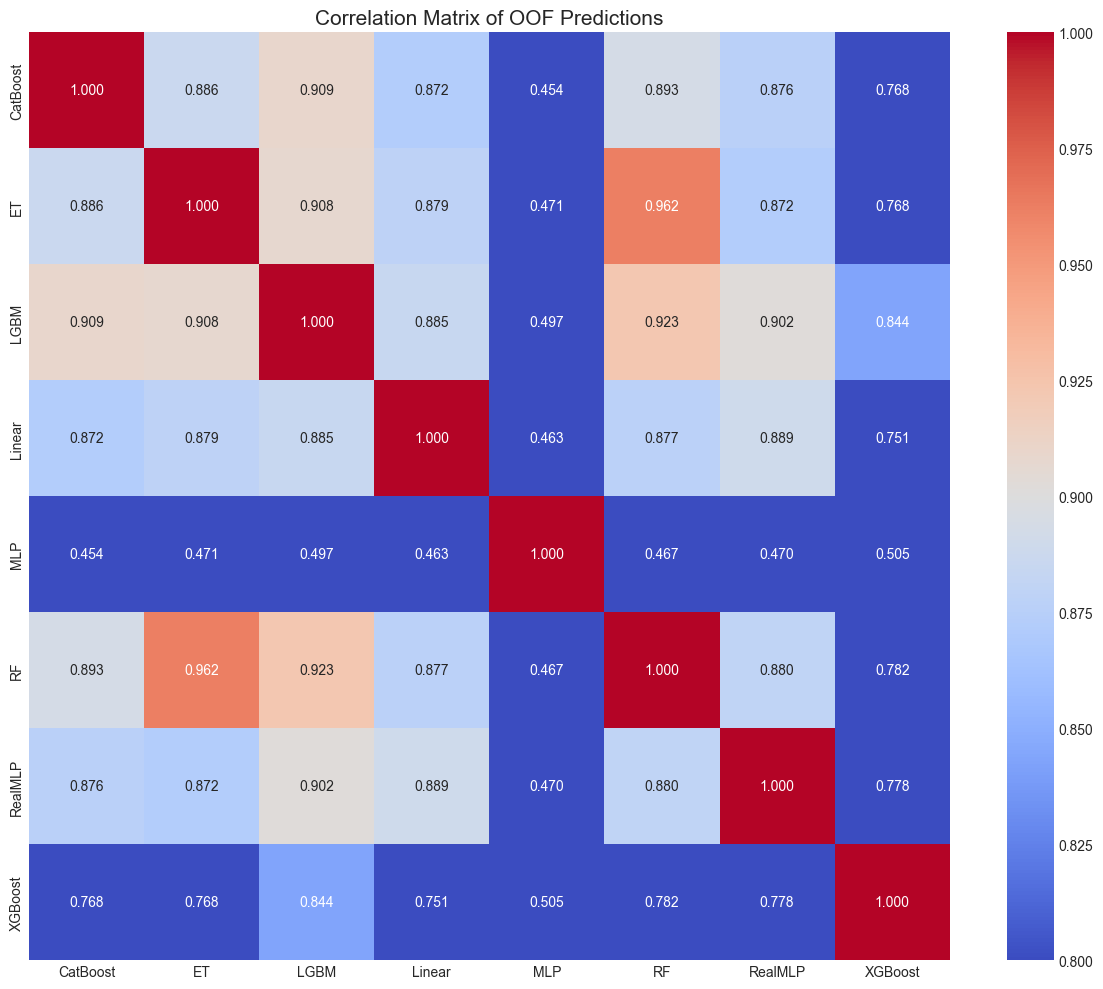


✅ 모든 모델이 적절한 다양성을 가지고 있습니다.


In [70]:
# ====================================================
# 1. 상관관계 분석 및 시각화 (Correlation Analysis)
# ====================================================
def plot_correlation_heatmap(oof_df, model_cols):
    """
    OOF 예측값들 간의 상관관계를 시각화합니다.
    상관계수가 높을수록(1.0에 가까울수록) 두 모델은 비슷하게 예측하므로,
    앙상블 효과가 적을 수 있습니다.
    """
    corr = oof_df[model_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=0.8, vmax=1.0)
    plt.title('Correlation Matrix of OOF Predictions', fontsize=15)
    plt.tight_layout()
    plt.show()
    
    return corr

# 실행
print("=== 📊 모델 상관관계 분석 ===")
corr_matrix = plot_correlation_heatmap(oof_matrix, model_names)

# (선택사항) 상관관계가 0.99 이상인 모델 쌍 출력
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.99:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️ 경고: 상관관계가 매우 높은 모델 쌍 (Pruning 고려):")
    for m1, m2, val in high_corr_pairs:
        print(f"  - {m1} <-> {m2}: {val:.4f}")
else:
    print("\n✅ 모든 모델이 적절한 다양성을 가지고 있습니다.")

---
## Ridge Stacking (Optuna)

In [71]:
# ====================================================
# 고급 스태킹 피처 생성 및 데이터 준비
# ====================================================
def add_meta_features(df, model_cols):
    """
    모델 예측값들의 통계적 특성을 새로운 피처로 추가합니다.
    """
    meta_df = df.copy()
    # 통계 피처 추가
    meta_df['mean_pred'] = df[model_cols].mean(axis=1)
    meta_df['std_pred']  = df[model_cols].std(axis=1)
    meta_df['min_pred']  = df[model_cols].min(axis=1)
    meta_df['max_pred']  = df[model_cols].max(axis=1)
    meta_df['median_pred'] = df[model_cols].median(axis=1)
    meta_df['range_pred'] = meta_df['max_pred'] - meta_df['min_pred']
    return meta_df

print("\n=== 🧠 Advanced Stacking 데이터 준비 ===")

# 1. 데이터 병합
train_stack = target_df.merge(oof_matrix, on=ID_COL)
test_stack = sub_matrix.copy()

# 2. 피처 생성
train_stack_feat = add_meta_features(train_stack, model_names)
test_stack_feat = add_meta_features(test_stack, model_names)

# 3. 학습용 데이터 변수 교체
# 기존 모델 예측값 + 통계 피처를 모두 사용
meta_cols = model_names + ['mean_pred', 'std_pred', 'min_pred', 'max_pred', 'median_pred', 'range_pred']

# ★ 중요: 여기서 X_train, X_test 변수를 덮어씌웁니다.
X_train = train_stack_feat[meta_cols].values
y_train = train_stack_feat[TARGET_COL].values
X_test = test_stack_feat[meta_cols].values

print(f"✅ 데이터 업그레이드 완료!")
print(f"   기존 피처: {len(model_names)}개 (모델 예측값)")
print(f"   추가 피처: 6개 (통계 피처)")
print(f"   최종 피처: {len(meta_cols)}개")
print(f"   Train Shape: {X_train.shape}")
print(f"   Test Shape: {X_test.shape}")


=== 🧠 Advanced Stacking 데이터 준비 ===
✅ 데이터 업그레이드 완료!
   기존 피처: 8개 (모델 예측값)
   추가 피처: 6개 (통계 피처)
   최종 피처: 14개
   Train Shape: (30000, 14)
   Test Shape: (19995, 14)


---
## 고급 스태킹 피처 생성 (Advanced Meta Features)

In [72]:
# ====================================================
# Ridge/Logistic Stacking (Optuna) - 범용 버전
# ====================================================
def objective_linear_stacking(trial):
    """Ridge(회귀) 또는 LogisticRegression(분류) 최적화"""
    if PROBLEM_TYPE == "CLASSIFICATION":
        C = trial.suggest_float('C', 0.001, 100.0, log=True)
        meta = get_meta_model({'C': C})
    else:
        alpha = trial.suggest_float('alpha', 0.001, 100.0, log=True)
        meta = get_meta_model({'alpha': alpha})
    
    cv_scores = []
    kf = get_cv_strategy(y_train)
    
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        meta.fit(X_fold_train, y_fold_train)
        y_pred = get_prediction(meta, X_fold_val)
        cv_scores.append(get_metric_function(y_fold_val, y_pred))
    
    return np.mean(cv_scores)

model_name = "LogisticRegression" if PROBLEM_TYPE == "CLASSIFICATION" else "Ridge"
print(f"\n=== 🔬 {model_name} Stacking (Optuna) ===\n")

study_linear = optuna.create_study(direction='minimize', study_name=f'{model_name}_Stacking')
study_linear.optimize(objective_linear_stacking, n_trials=OPTUNA_TRIALS["Ridge"], show_progress_bar=True)

metric_name = METRIC
print(f"\n🎯 {model_name} Stacking {metric_name}: {study_linear.best_value:.6f}")
print(f"📊 Best params: {study_linear.best_params}")

# 최종 모델 학습
if PROBLEM_TYPE == "CLASSIFICATION":
    meta_best = get_meta_model({'C': study_linear.best_params['C']})
else:
    meta_best = get_meta_model({'alpha': study_linear.best_params['alpha']})

# CV로 OOF 생성
kf = get_cv_strategy(y_train)
oof_linear = np.zeros(len(X_train))

for train_idx, val_idx in kf.split(X_train, y_train):
    meta_best.fit(X_train[train_idx], y_train[train_idx])
    oof_linear[val_idx] = get_prediction(meta_best, X_train[val_idx])

meta_best.fit(X_train, y_train)
sub_linear = get_prediction(meta_best, X_test)

# 결과 저장
merged = target_df.merge(oof_matrix, on=ID_COL)
pd.DataFrame({ID_COL: merged[ID_COL], TARGET_COL: oof_linear}).to_csv(f"{OUTPUT_DIR}/oof_{model_name.lower()}_stacking.csv", index=False)
pd.DataFrame({ID_COL: sub_matrix[ID_COL], TARGET_COL: sub_linear}).to_csv(f"{OUTPUT_DIR}/submission_{model_name.lower()}_stacking.csv", index=False)
print(f"\n✅ Saved: oof_{model_name.lower()}_stacking.csv, submission_{model_name.lower()}_stacking.csv")

[I 2025-12-08 16:19:52,631] A new study created in memory with name: LogisticRegression_Stacking



=== 🔬 LogisticRegression Stacking (Optuna) ===



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-08 16:19:52,714] Trial 0 finished with value: -0.7163337302306328 and parameters: {'C': 0.01002822100789132}. Best is trial 0 with value: -0.7163337302306328.
[I 2025-12-08 16:19:52,791] Trial 1 finished with value: -0.7147710605202375 and parameters: {'C': 0.004786062647063863}. Best is trial 0 with value: -0.7163337302306328.
[I 2025-12-08 16:19:52,791] Trial 1 finished with value: -0.7147710605202375 and parameters: {'C': 0.004786062647063863}. Best is trial 0 with value: -0.7163337302306328.
[I 2025-12-08 16:19:52,921] Trial 2 finished with value: -0.7173241912552556 and parameters: {'C': 36.448769787010605}. Best is trial 2 with value: -0.7173241912552556.
[I 2025-12-08 16:19:52,993] Trial 3 finished with value: -0.7137449015406508 and parameters: {'C': 0.003474032469459413}. Best is trial 2 with value: -0.7173241912552556.
[I 2025-12-08 16:19:52,921] Trial 2 finished with value: -0.7173241912552556 and parameters: {'C': 36.448769787010605}. Best is trial 2 with value: 

---
## XGBoost Stacking (Optuna)

In [73]:
# ====================================================
# XGBoost Stacking (Optuna) - 범용 버전
# ====================================================
def objective_xgb(trial):
    """XGBoost Regressor/Classifier 자동 최적화"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'verbosity': 0
    }
    
    meta = get_tree_model('xgb', params)
    
    cv_scores = []
    kf = get_cv_strategy(y_train)
    
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        meta.fit(X_fold_train, y_fold_train)
        y_pred = get_prediction(meta, X_fold_val)
        cv_scores.append(get_metric_function(y_fold_val, y_pred))
    
    return np.mean(cv_scores)

print(f"\n=== 🔬 XGBoost Stacking (Optuna, {PROBLEM_TYPE}) ===\n")
study_xgb = optuna.create_study(direction='minimize', study_name='XGBoost_Stacking')
study_xgb.optimize(objective_xgb, n_trials=OPTUNA_TRIALS["XGBoost"], show_progress_bar=True)

metric_name = METRIC
print(f"\n🎯 XGBoost Stacking {metric_name}: {study_xgb.best_value:.6f}")

# 최종 모델 학습
best_params = study_xgb.best_params
best_params['random_state'] = RANDOM_STATE
best_params['verbosity'] = 0
meta_best = get_tree_model('xgb', best_params)

# CV로 OOF 생성
kf = get_cv_strategy(y_train)
oof_xgb = np.zeros(len(X_train))

for train_idx, val_idx in kf.split(X_train, y_train):
    meta_best.fit(X_train[train_idx], y_train[train_idx])
    oof_xgb[val_idx] = get_prediction(meta_best, X_train[val_idx])

meta_best.fit(X_train, y_train)
sub_xgb = get_prediction(meta_best, X_test)

# 결과 저장
pd.DataFrame({ID_COL: merged[ID_COL], TARGET_COL: oof_xgb}).to_csv(f"{OUTPUT_DIR}/oof_xgb_stacking.csv", index=False)
pd.DataFrame({ID_COL: sub_matrix[ID_COL], TARGET_COL: sub_xgb}).to_csv(f"{OUTPUT_DIR}/submission_xgb_stacking.csv", index=False)
print(f"\n✅ Saved: oof_xgb_stacking.csv, submission_xgb_stacking.csv")

[I 2025-12-08 16:19:58,013] A new study created in memory with name: XGBoost_Stacking



=== 🔬 XGBoost Stacking (Optuna, CLASSIFICATION) ===



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-08 16:19:58,376] Trial 0 finished with value: -0.7168480172513119 and parameters: {'n_estimators': 110, 'max_depth': 3, 'learning_rate': 0.056121445529580365, 'subsample': 0.9214687738307398, 'colsample_bytree': 0.6231604380859936, 'min_child_weight': 8, 'reg_alpha': 1.8430049015600904e-06, 'reg_lambda': 1.3877518604286765e-06}. Best is trial 0 with value: -0.7168480172513119.
[I 2025-12-08 16:19:59,322] Trial 1 finished with value: -0.7168770091533077 and parameters: {'n_estimators': 286, 'max_depth': 4, 'learning_rate': 0.0011054799642590796, 'subsample': 0.6908333163697166, 'colsample_bytree': 0.7280832154505361, 'min_child_weight': 7, 'reg_alpha': 2.6684442018531358e-08, 'reg_lambda': 6.47645845098901e-08}. Best is trial 1 with value: -0.7168770091533077.
[I 2025-12-08 16:19:59,322] Trial 1 finished with value: -0.7168770091533077 and parameters: {'n_estimators': 286, 'max_depth': 4, 'learning_rate': 0.0011054799642590796, 'subsample': 0.6908333163697166, 'colsample_bytr

---
## LightGBM Stacking (Optuna)

In [74]:
# ====================================================
# LightGBM Stacking (Optuna) - 범용 버전
# ====================================================
def objective_lgb(trial):
    """LightGBM Regressor/Classifier 자동 최적화"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'random_state': RANDOM_STATE,
        'verbose': -1
    }
    
    meta = get_tree_model('lgb', params)
    
    cv_scores = []
    kf = get_cv_strategy(y_train)
    
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        meta.fit(X_fold_train, y_fold_train)
        y_pred = get_prediction(meta, X_fold_val)
        cv_scores.append(get_metric_function(y_fold_val, y_pred))
    
    return np.mean(cv_scores)

print(f"\n=== 🔬 LightGBM Stacking (Optuna, {PROBLEM_TYPE}) ===\n")
study_lgb = optuna.create_study(direction='minimize', study_name='LightGBM_Stacking')
study_lgb.optimize(objective_lgb, n_trials=OPTUNA_TRIALS["LightGBM"], show_progress_bar=True)

metric_name = METRIC
print(f"\n🎯 LightGBM Stacking {metric_name}: {study_lgb.best_value:.6f}")

# 최종 모델 학습
best_params = study_lgb.best_params
best_params['random_state'] = RANDOM_STATE
best_params['verbose'] = -1
meta_best = get_tree_model('lgb', best_params)

# CV로 OOF 생성
kf = get_cv_strategy(y_train)
oof_lgb = np.zeros(len(X_train))

for train_idx, val_idx in kf.split(X_train, y_train):
    meta_best.fit(X_train[train_idx], y_train[train_idx])
    oof_lgb[val_idx] = get_prediction(meta_best, X_train[val_idx])

meta_best.fit(X_train, y_train)
sub_lgb = get_prediction(meta_best, X_test)

# 결과 저장
pd.DataFrame({ID_COL: merged[ID_COL], TARGET_COL: oof_lgb}).to_csv(f"{OUTPUT_DIR}/oof_lgb_stacking.csv", index=False)
pd.DataFrame({ID_COL: sub_matrix[ID_COL], TARGET_COL: sub_lgb}).to_csv(f"{OUTPUT_DIR}/submission_lgb_stacking.csv", index=False)
print(f"\n✅ Saved: oof_lgb_stacking.csv, submission_lgb_stacking.csv")

[I 2025-12-08 16:20:46,694] A new study created in memory with name: LightGBM_Stacking



=== 🔬 LightGBM Stacking (Optuna, CLASSIFICATION) ===



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-08 16:20:47,078] Trial 0 finished with value: -0.7077777829146513 and parameters: {'n_estimators': 140, 'max_depth': 7, 'learning_rate': 0.07795951499559327, 'subsample': 0.9740467475054378, 'colsample_bytree': 0.7468317572219945, 'min_child_samples': 87, 'reg_alpha': 0.00010493538969954093, 'reg_lambda': 1.7278538008438825e-05, 'num_leaves': 39}. Best is trial 0 with value: -0.7077777829146513.
[I 2025-12-08 16:20:47,276] Trial 1 finished with value: -0.7155235380917611 and parameters: {'n_estimators': 62, 'max_depth': 7, 'learning_rate': 0.00682823301258357, 'subsample': 0.9373936238035966, 'colsample_bytree': 0.7532873055481928, 'min_child_samples': 75, 'reg_alpha': 0.014106244019547687, 'reg_lambda': 4.2840160252354756e-07, 'num_leaves': 19}. Best is trial 1 with value: -0.7155235380917611.
[I 2025-12-08 16:20:47,988] Trial 2 finished with value: -0.6824407699122916 and parameters: {'n_estimators': 265, 'max_depth': 8, 'learning_rate': 0.15642163905363293, 'subsample': 0

---
## 최종 성능 비교


🏆 최종 앙상블 챔피언 결정전 (CLASSIFICATION - AUC (Higher is Better))
🥇 Hill Climbing                  : -0.718273
   Optuna Weights                 : -0.718234
   LogisticRegression Stacking    : -0.717597
   XGBoost Stacking               : -0.717244
   LightGBM Stacking              : -0.717198
   Scipy Weights                  : -0.713505
   Simple Average                 : -0.710798
----------------------------------------------------------------------
🎉 최종 우승 모델: [Hill Climbing]
🎉 최종 AUC: -0.718273


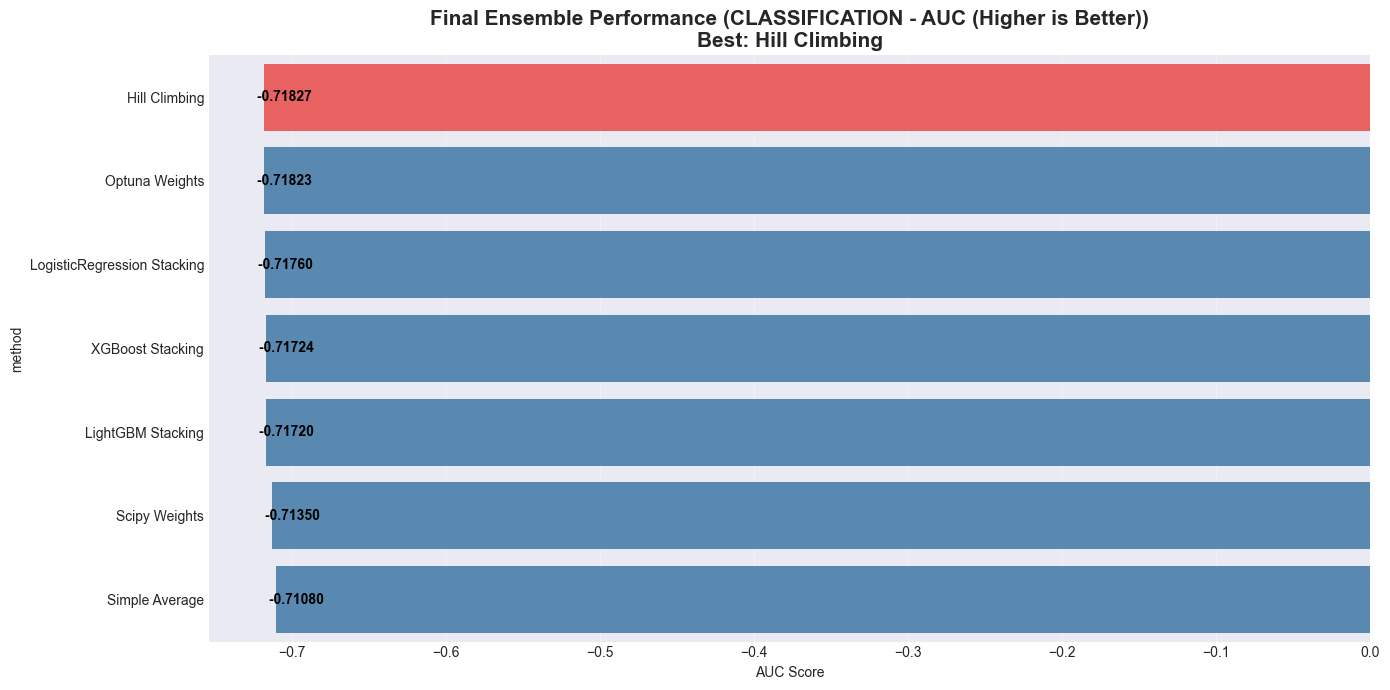


✅ 최종 결과 저장 완료: C:\SEMIN\Project\ML_FINAL\5.ENSEMBLE_SUBMISSION


In [75]:
# ====================================================
# 🏆 최종 성능 비교 (회귀/분류 범용)
# ====================================================

# 1. 모든 결과 취합
metric_name = METRIC  # ⭐ 직접 METRIC 변수 사용
metric_display = f"{METRIC} ({'Higher' if METRIC in ['AUC', 'ACCURACY', 'R2'] else 'Lower'} is Better)"
linear_name = "LogisticRegression" if PROBLEM_TYPE == "CLASSIFICATION" else "Ridge"


final_results = [
    {'method': 'Simple Average', 'score': score_avg},
    {'method': 'Scipy Weights', 'score': score_scipy},
    {'method': 'Optuna Weights', 'score': study_weights.best_value},
    {'method': 'Hill Climbing', 'score': score_hc},
    {'method': f'{linear_name} Stacking', 'score': study_linear.best_value},
    {'method': 'XGBoost Stacking', 'score': study_xgb.best_value},
    {'method': 'LightGBM Stacking', 'score': study_lgb.best_value}
]

# 2. DataFrame 변환 및 정렬
final_comparison = pd.DataFrame(final_results).sort_values('score')
best_method_name = final_comparison.iloc[0]['method']
best_score = final_comparison.iloc[0]['score']

# 3. 텍스트 리포트
print("\n" + "="*70)
print(f"🏆 최종 앙상블 챔피언 결정전 ({PROBLEM_TYPE} - {metric_display})")
print("="*70)

for idx, row in final_comparison.iterrows():
    prefix = "🥇 " if row['method'] == best_method_name else "   "
    print(f"{prefix}{row['method']:30s} : {row['score']:.6f}")

print("-" * 70)
print(f"🎉 최종 우승 모델: [{best_method_name}]")
print(f"🎉 최종 {metric_name}: {best_score:.6f}")
print("=" * 70)

# 4. 그래프 시각화 (1등 강조)
plt.figure(figsize=(14, 7))
colors = ['#FF4B4B' if m == best_method_name else '#4B8BBE' for m in final_comparison['method']]
ax = sns.barplot(x='score', y='method', data=final_comparison, palette=colors)

# 그래프 위에 점수 표시
for i, v in enumerate(final_comparison['score']):
    ax.text(v + v*0.01, i, f" {v:.5f}", color='black', va='center', fontweight='bold')

plt.title(f'Final Ensemble Performance ({PROBLEM_TYPE} - {metric_display})\nBest: {best_method_name}', 
          fontsize=15, fontweight='bold')
plt.xlabel(f'{METRIC} Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/final_championship_{PROBLEM_TYPE.lower()}.png", dpi=150)
plt.show()

# 최종 결과 저장
final_comparison_renamed = final_comparison.rename(columns={'score': metric_name.lower()})
final_comparison_renamed.to_csv(f"{OUTPUT_DIR}/final_ensemble_rank_{PROBLEM_TYPE.lower()}.csv", index=False)
print(f"\n✅ 최종 결과 저장 완료: {OUTPUT_DIR}")